# Stock Prediction Project

This notebook performs data analysis, visualization, statistical testing, and machine learning on stock data.

##  1. Import Libraries

We import all required libraries for data handling, visualization, machine learning, and statistical testing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from scipy import stats
import seaborn as sns
import yfinance as yf

##  2. Load Dataset

Load stock dataset from a CSV file. Replace 'stock_data.csv' with your dataset.

In [ ]:
ticker = "AAPL"
df = yf.download(ticker, period="1mo", interval="5m")
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2026-03-16 13:30:00+00:00,251.520004,252.199997,249.910004,252.104996,1867053
2026-03-16 13:35:00+00:00,252.000000,252.309998,251.380005,251.490097,0
2026-03-16 13:40:00+00:00,251.559998,252.300003,251.403000,251.929993,281037
2026-03-16 13:45:00+00:00,252.380005,252.580002,251.610001,251.610001,456211
2026-03-16 13:50:00+00:00,252.779999,252.785004,252.020004,252.389999,240989


##  3. Data Cleaning

Handle missing values and format date column if present.

In [ ]:
df.dropna(inplace=True)

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1560.000000,1560.000000,1560.000000,1560.000000,1.560000e+03
mean,253.567881,253.819144,253.321461,253.568937,4.293384e+05
std,3.883394,3.860561,3.897828,3.876318,7.708974e+05
min,245.529999,245.949997,245.509995,245.509995,0.000000e+00
25%,251.026272,251.343754,250.763748,251.030003,1.736598e+05
50%,253.507500,253.764999,253.199997,253.529999,2.445200e+05
75%,256.528763,257.002502,256.306244,256.543877,3.756440e+05
max,261.975006,262.190002,261.751587,261.954987,1.080174e+07


##  4. Feature Engineering

Create new useful features for analysis.

In [ ]:
df['Price_Change'] = df['Close'] - df['Open']
df['High_Low_Diff'] = df['High'] - df['Low']

##  5. Data Visualization

Different plots to understand trends, distributions, and relationships.

### Line Plot

This visualization helps analyze line plot of stock data.

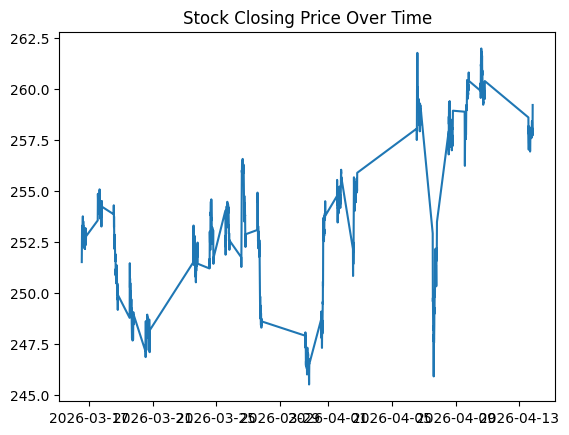

In [ ]:
plt.figure()
plt.plot(df['Close'])
plt.title('Stock Closing Price Over Time')
plt.show()

### Histogram

This visualization helps analyze histogram of stock data.

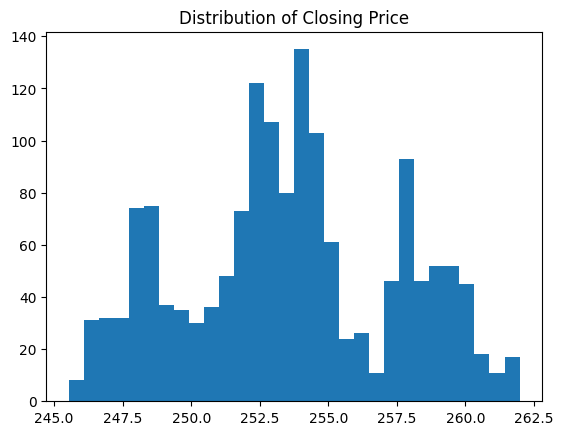

In [ ]:
plt.figure()
plt.hist(df['Close'], bins=30)
plt.title('Distribution of Closing Price')
plt.show()

### Scatter Plot

This visualization helps analyze scatter plot of stock data.

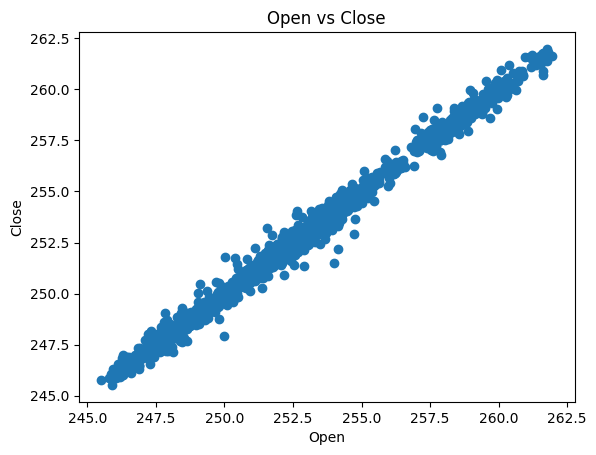

In [ ]:
plt.figure()
plt.scatter(df['Open'], df['Close'])
plt.title('Open vs Close')
plt.xlabel('Open')
plt.ylabel('Close')
plt.show()

### Bar Chart

This visualization helps analyze bar chart of stock data.

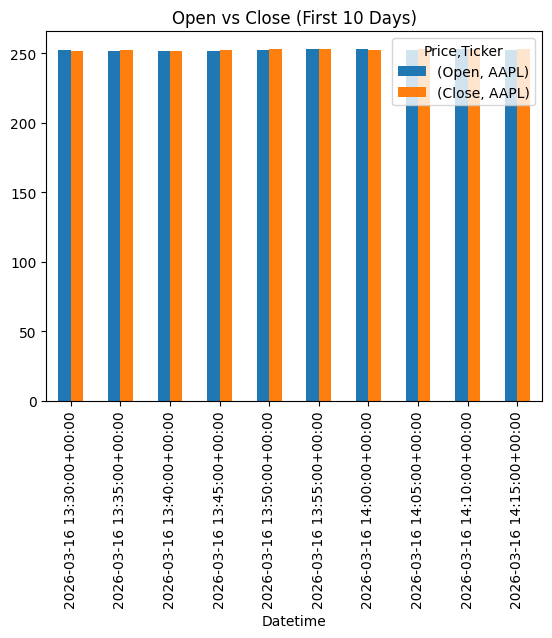

In [ ]:
df[['Open', 'Close']].head(10).plot(kind='bar')
plt.title('Open vs Close (First 10 Days)')
plt.show()

### Pie Chart

This visualization helps analyze pie chart of stock data.

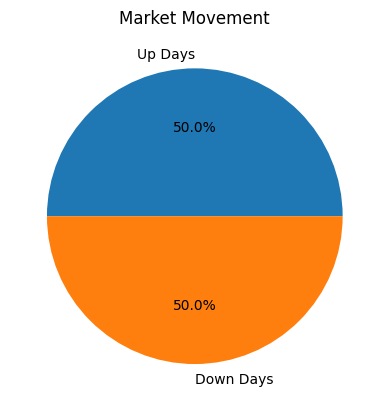

In [ ]:
labels = ['Up Days', 'Down Days']
sizes = [
    len(df[df['Close'] > df['Open']]),
    len(df[df['Close'] <= df['Open']])
]

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Market Movement')
plt.show()

### Box Plot

This visualization helps analyze box plot of stock data.

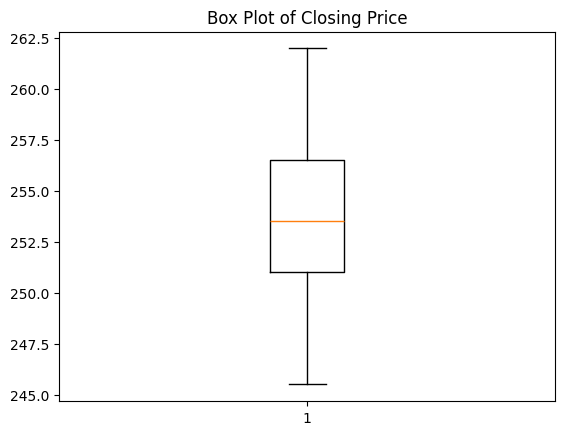

In [ ]:
plt.figure()
plt.boxplot(df['Close'])
plt.title('Box Plot of Closing Price')
plt.show()

### Heatmap

This visualization helps analyze heatmap of stock data.

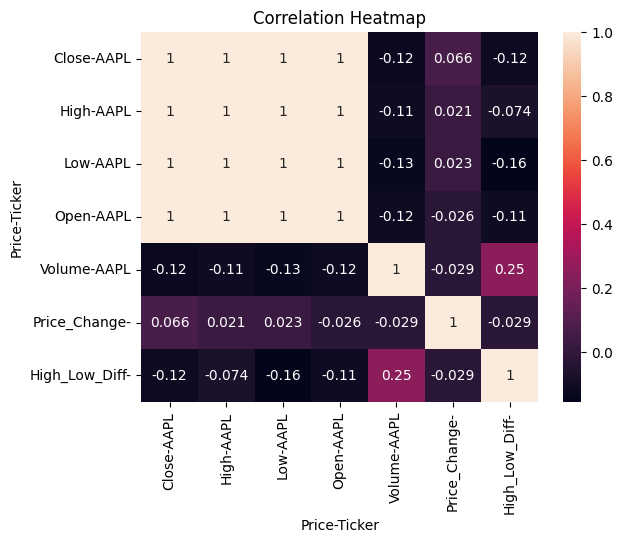

In [ ]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

### Pair Plot

This visualization helps analyze pair plot of stock data.

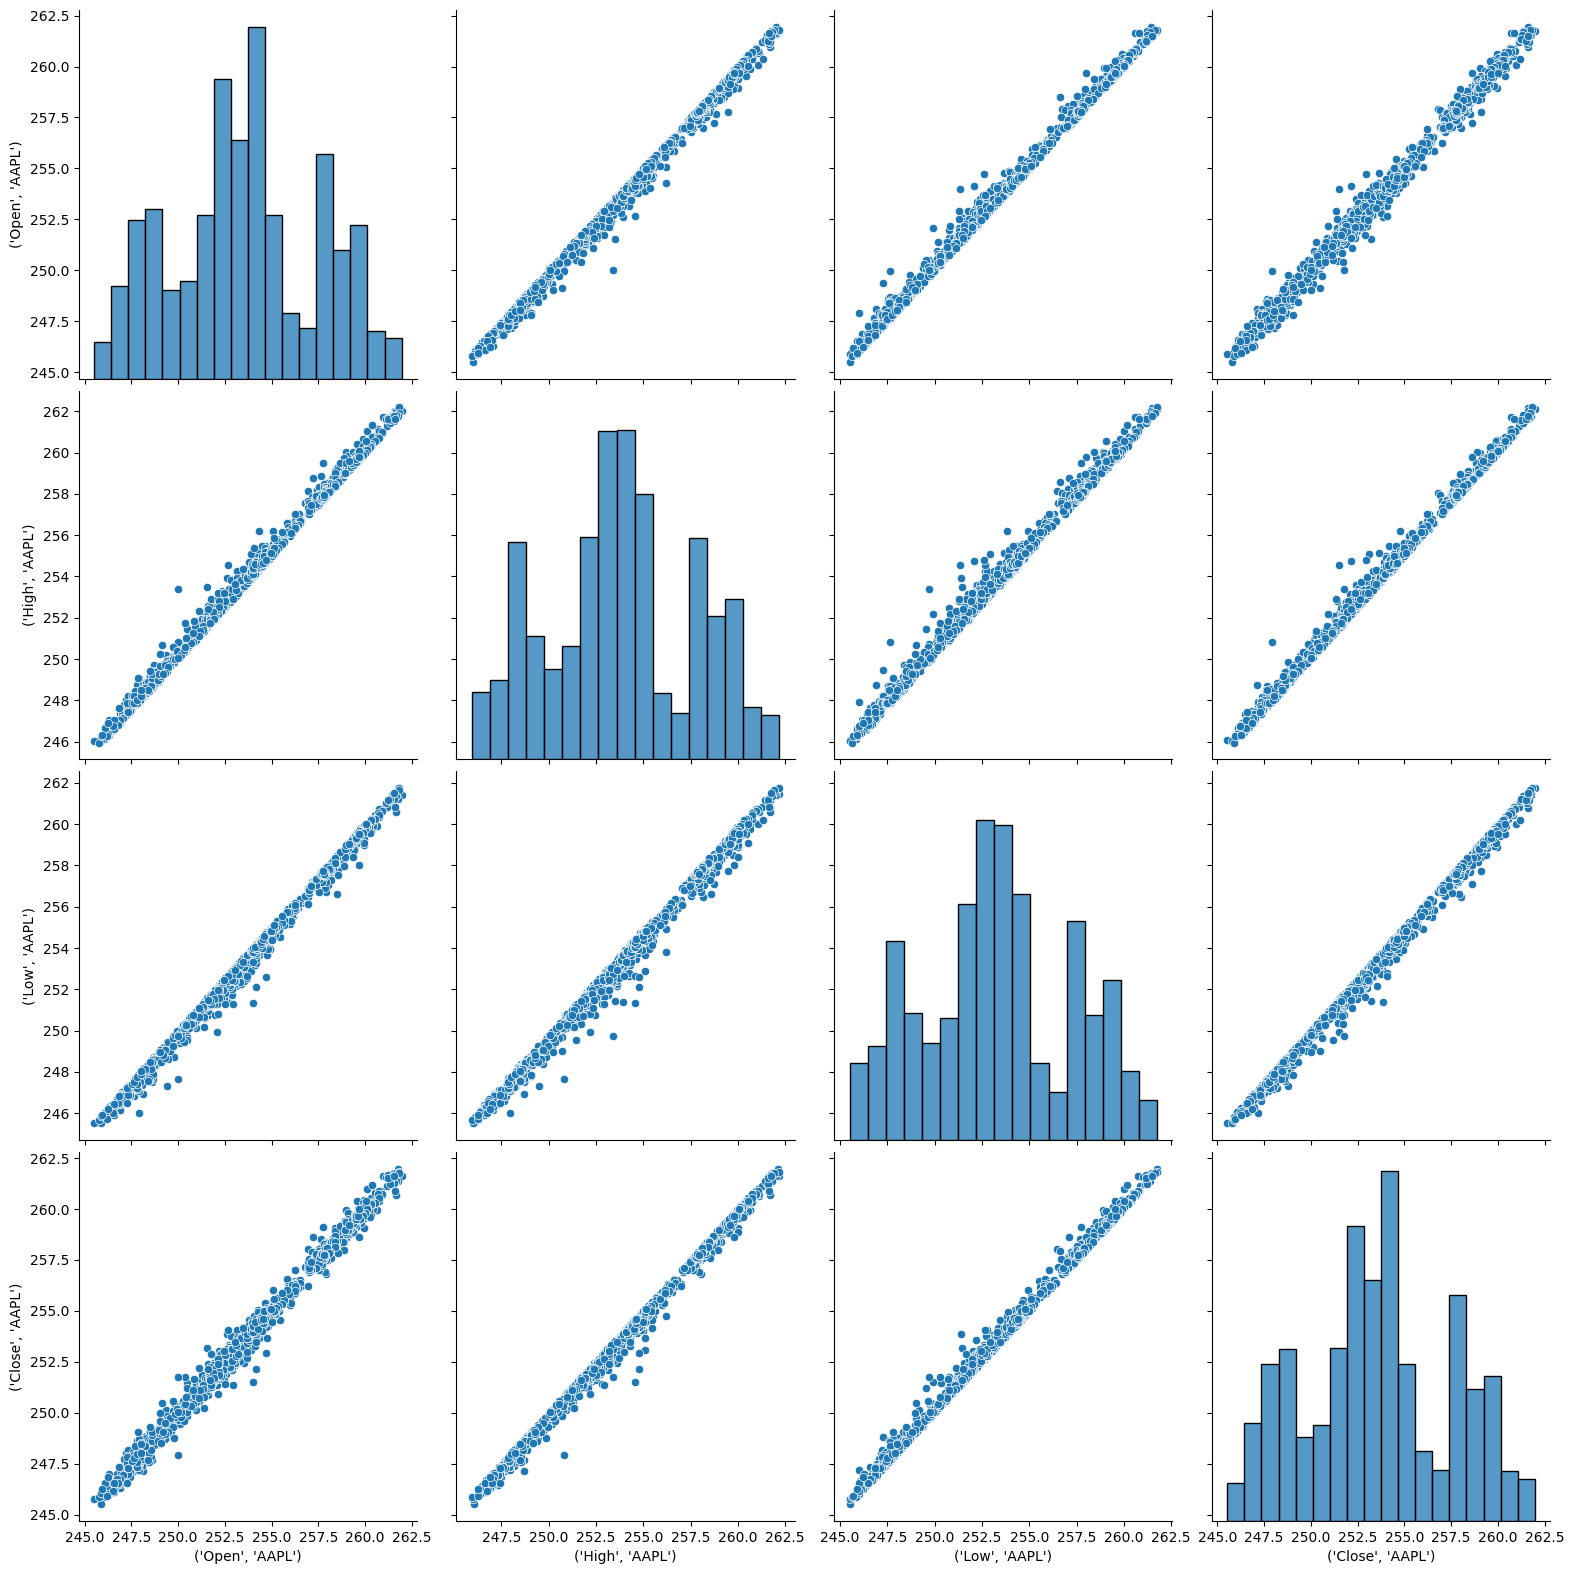

In [ ]:
sns.pairplot(df[['Open', 'High', 'Low', 'Close']],height=4)
plt.show()

##  6. Statistical Testing (t-test)

Compare closing prices of up days vs down days.

In [ ]:
up_days = df[df['Close'] > df['Open']]['Close']
down_days = df[df['Close'] <= df['Open']]['Close']

t_stat, p_value = stats.ttest_ind(up_days, down_days)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Statistically significant difference")
else:
    print("No significant difference")

T-statistic: [nan]
P-value: [nan]
No significant difference


## 8. Outlier Detection
This section identifies and visualizes outliers in the dataset using the IQR (Interquartile Range) method.

In [ ]:
# Select numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns

print("Outlier count per column:\n")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)}")

# Boxplot visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

NameError: name 'df' is not defined

##  7. Model Building

Train a Linear Regression model to predict closing prices.

In [ ]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


##  8. Model Evaluation

Evaluate model performance using MAE and R² score.

In [ ]:
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.10911355510307694
R2 Score: 0.9982925952002305


##  9. Prediction Visualization

Compare actual vs predicted values.

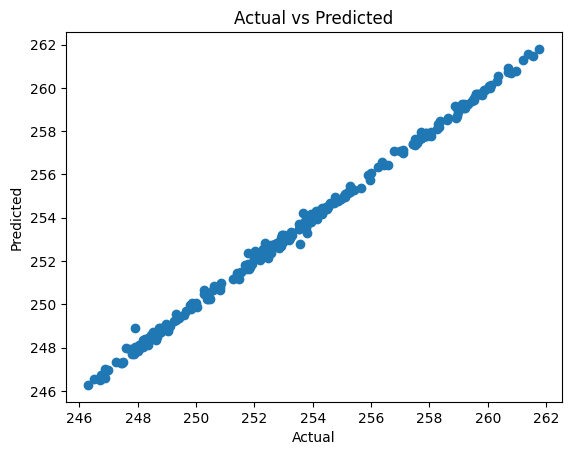

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.title('Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()